# Emotion Analysis with NLP — Text Emotion Classifier

This notebook builds a **text emotion classification** model (sadness, joy, love, anger, fear, surprise)
using the open-source **`dair-ai/emotion`** dataset (~20,000 English Twitter messages, CARER paper, Saravia et al. 2018),
classic NLP feature engineering (TF‑IDF), and several ML models compared head-to-head. The best model is exported
and served through a **Streamlit** web app (`app.py`, in the same folder).



## Environment Setup



In [46]:
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment ready.")


Environment ready.


## Load the Dataset

We use **dair-ai/emotion** (Saravia et al., *CARER: Contextualized Affect Representations for Emotion Recognition*,
EMNLP 2018) — a widely used, open-source, English Twitter emotion dataset with 6 labels:
`sadness, joy, love, anger, fear, surprise`. It ships with pre-made train / validation / test splits so evaluation
is clean and comparable to published results.



In [47]:
DATA_DIR = "data"
import os
os.makedirs(DATA_DIR, exist_ok=True)

def load_emotion_dataset():
    """Try the Hugging Face `datasets` library first; fall back to a local CSV."""
    try:
        from datasets import load_dataset
        ds = load_dataset("dair-ai/emotion", "split")
        label_names = ds["train"].features["label"].names

        def to_df(split):
            df = ds[split].to_pandas()
            df["emotion"] = df["label"].apply(lambda i: label_names[i])
            return df[["text", "emotion"]]

        train_df = to_df("train")
        val_df = to_df("validation")
        test_df = to_df("test")
        print("Loaded dair-ai/emotion via the `datasets` library.")
        return train_df, val_df, test_df

    except Exception as e:
        print("Could not download automatically:", e)
        print("""
FALLBACK — manual download:
1. Go to https://www.kaggle.com/datasets/parulpandey/emotion-dataset (free Kaggle account required)
2. Download and unzip it into the `data/` folder next to this notebook
   (you should get train.txt / val.txt / test.txt or similarly named CSVs, format: "text;emotion" per line)
3. Re-run this cell — the code below will pick up files placed in data/train.txt, data/val.txt, data/test.txt
""")
        def read_txt(path):
            return pd.read_csv(path, sep=";", header=None, names=["text", "emotion"])

        train_df = read_txt(os.path.join(DATA_DIR, "train.txt"))
        val_df = read_txt(os.path.join(DATA_DIR, "val.txt"))
        test_df = read_txt(os.path.join(DATA_DIR, "test.txt"))
        return train_df, val_df, test_df

train_df, val_df, test_df = load_emotion_dataset()
print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
train_df.head()


Loaded dair-ai/emotion via the `datasets` library.
Train: 16000  |  Val: 2000  |  Test: 2000


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [48]:

train_df.to_csv(os.path.join(DATA_DIR, "train_clean_raw.csv"), index=False)
val_df.to_csv(os.path.join(DATA_DIR, "val_clean_raw.csv"), index=False)
test_df.to_csv(os.path.join(DATA_DIR, "test_clean_raw.csv"), index=False)


## 3. Exploratory Data Analysis (EDA)

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


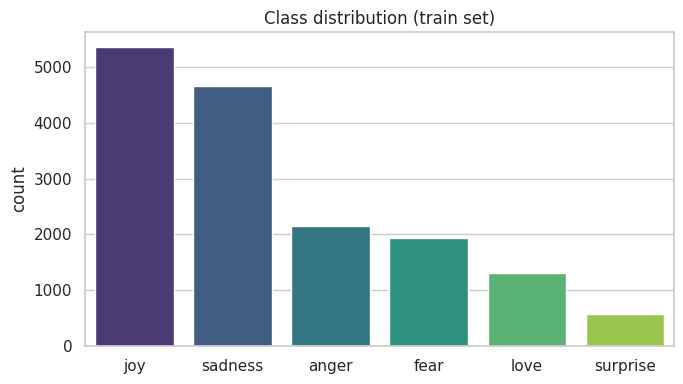

In [49]:
print(train_df["emotion"].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
order = train_df["emotion"].value_counts().index
sns.countplot(data=train_df, x="emotion", order=order, palette="viridis", ax=ax)
ax.set_title("Class distribution (train set)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


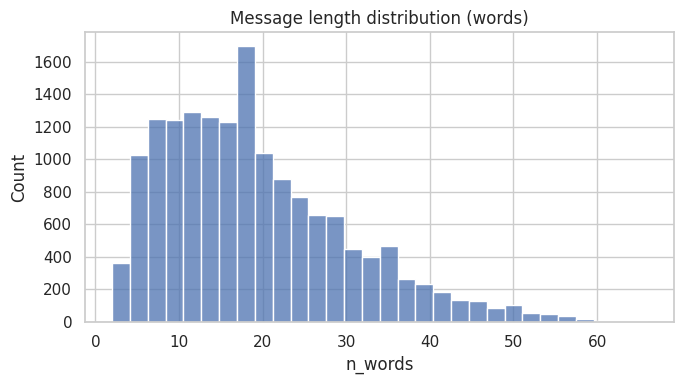

,n_words
count,16000.000000
mean,19.166313
std,10.986905
min,2.000000
25%,11.000000
50%,17.000000
75%,25.000000
max,66.000000


In [50]:
train_df["n_words"] = train_df["text"].str.split().apply(len)
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(train_df["n_words"], bins=30, ax=ax)
ax.set_title("Message length distribution (words)")
plt.tight_layout()
plt.show()
train_df["n_words"].describe()


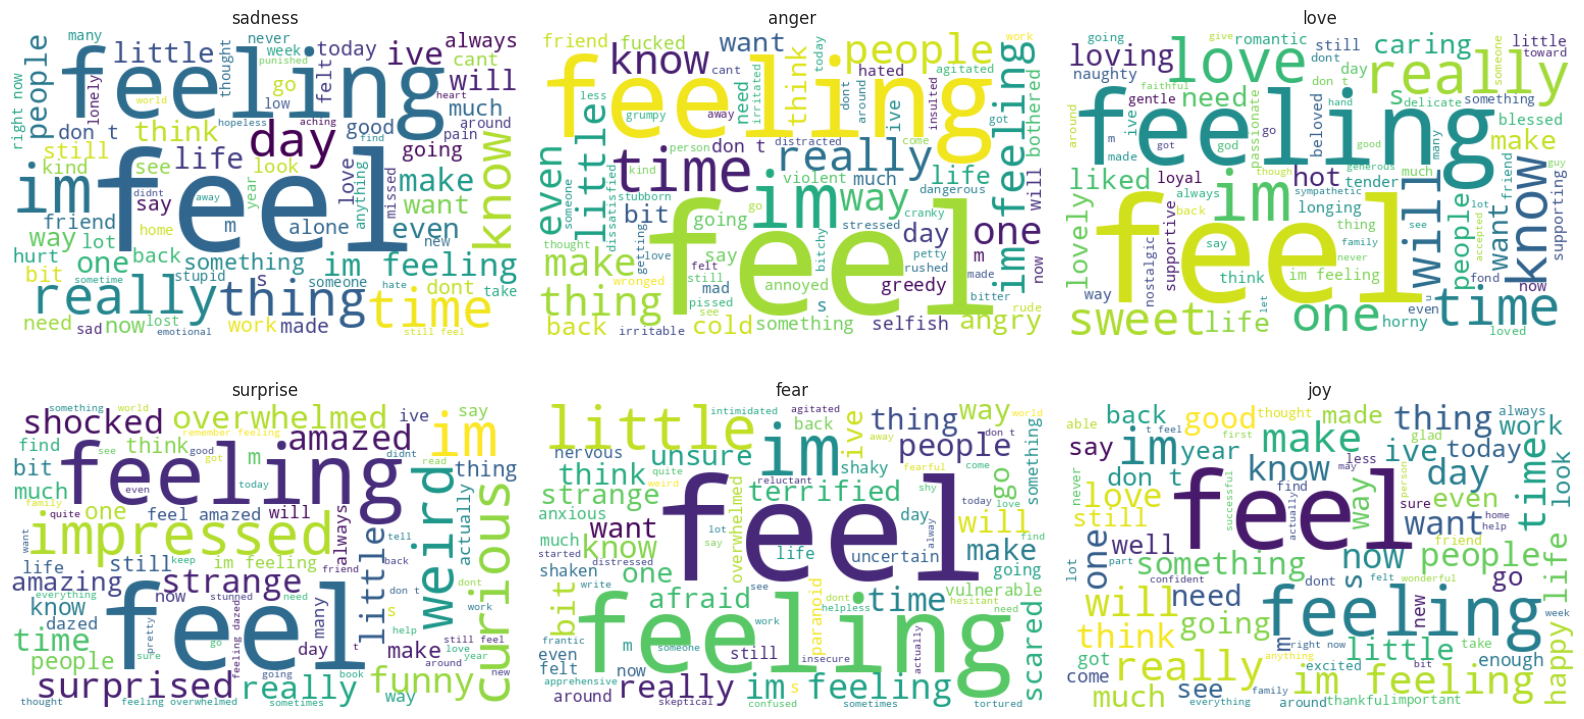

In [51]:
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, emo in zip(axes.flatten(), train_df["emotion"].unique()):
    text = " ".join(train_df.loc[train_df["emotion"] == emo, "text"])
    wc = WordCloud(width=500, height=300, background_color="white", max_words=80).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(emo)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Text Cleaning & Preprocessing


In [52]:
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words("english"))
# Keep negations - they flip emotional meaning and matter a lot for this task
NEGATIONS = {"no", "not", "nor", "never", "n't"}
STOPWORDS -= NEGATIONS
lemmatizer = WordNetLemmatizer()

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = NON_ALPHA_RE.sub(" ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

# quick sanity check
clean_text("I can't believe it, I'm SO happy!! check https://x.com @friend")


'believe happy check'

In [53]:
for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(clean_text)

train_df[["text", "clean_text", "emotion"]].sample(5, random_state=RANDOM_STATE)


,text,clean_text,emotion
8756,ive made it through a week i just feel beaten ...,ive made week feel beaten,sadness
4660,i feel this strategy is worthwhile,feel strategy worthwhile,joy
6095,i feel so worthless and weak what does he have...,feel worthless weak say want find,sadness
304,i feel clever nov,feel clever nov,joy
8241,im moved in ive been feeling kind of gloomy,im moved ive feeling kind gloomy,sadness


## Feature Engineering — TF-IDF



In [54]:
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_df["clean_text"])
X_val = vectorizer.transform(val_df["clean_text"])
X_test = vectorizer.transform(test_df["clean_text"])

y_train = train_df["emotion"]
y_val = val_df["emotion"]
y_test = test_df["emotion"]

X_train.shape, X_val.shape, X_test.shape


((16000, 15000), (2000, 15000), (2000, 15000))

## Train and Compare multiple models



In [55]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred, average="macro")
    results.append({"model": name, "val_accuracy": acc, "val_macro_f1": f1})
    print(f"{name:28s}  val_accuracy={acc:.4f}  val_macro_f1={f1:.4f}")

results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)
results_df


Multinomial Naive Bayes       val_accuracy=0.7295  val_macro_f1=0.5265
Logistic Regression           val_accuracy=0.9085  val_macro_f1=0.8841
Linear SVM                    val_accuracy=0.9085  val_macro_f1=0.8790
Random Forest                 val_accuracy=0.8925  val_macro_f1=0.8709


,model,val_accuracy,val_macro_f1
1,Logistic Regression,0.9085,0.884133
2,Linear SVM,0.9085,0.879031
3,Random Forest,0.8925,0.870939
0,Multinomial Naive Bayes,0.7295,0.526459


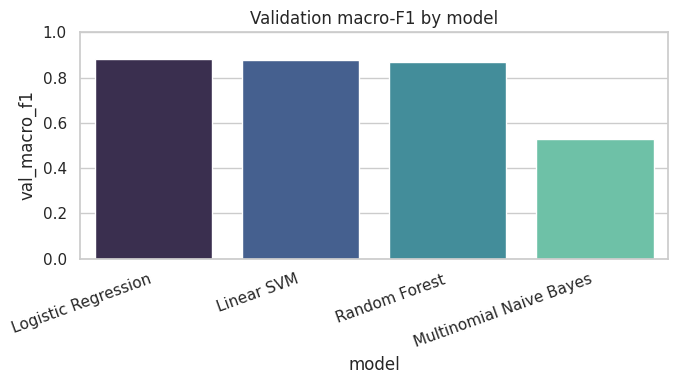

In [56]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=results_df, x="model", y="val_macro_f1", palette="mako", ax=ax)
ax.set_title("Validation macro-F1 by model")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## Hyperparameter Tuning of the Best Model



In [ ]:
best_model_name = results_df.iloc[0]["model"]
print("Best model from comparison:", best_model_name)

if best_model_name == "Linear SVM":
    base_estimator = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)
    param_grid = {"C": [0.1, 0.5, 1, 2, 5]}
elif best_model_name == "Logistic Regression":
    base_estimator = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    param_grid = {"C": [0.5, 1, 2, 5, 10], "solver": ["liblinear", "lbfgs"]}
elif best_model_name == "Multinomial Naive Bayes":
    base_estimator = MultinomialNB()
    param_grid = {"alpha": [0.01, 0.1, 0.5, 1.0]}
else:
    base_estimator = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    param_grid = {"n_estimators": [200, 400], "max_depth": [None, 40]}

grid = GridSearchCV(base_estimator, param_grid, scoring="f1_macro", cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)
tuned_model = grid.best_estimator_


Best model from comparison: Logistic Regression
Fitting 3 folds for each of 10 candidates, totalling 30 fits


## Final Evaluation



In [ ]:
test_pred = tuned_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average="macro")

print(f"TEST ACCURACY : {test_acc:.4f}")
print(f"TEST MACRO-F1 : {test_macro_f1:.4f}\n")
print(classification_report(y_test, test_pred, digits=3))


In [ ]:
labels_sorted = sorted(y_test.unique())
cm = confusion_matrix(y_test, test_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30)
ax.set_title(f"Confusion Matrix — Test Accuracy {test_acc:.1%}")
plt.tight_layout()
plt.show()


## Error Analysis


In [ ]:
test_df_eval = test_df.copy()
test_df_eval["predicted"] = test_pred
misclassified = test_df_eval[test_df_eval["emotion"] != test_df_eval["predicted"]]

print(f"{len(misclassified)} / {len(test_df_eval)} misclassified ({len(misclassified)/len(test_df_eval):.1%})")
misclassified[["text", "emotion", "predicted"]].sample(min(10, len(misclassified)), random_state=RANDOM_STATE)


In [ ]:
confusions = (
    misclassified.groupby(["emotion", "predicted"]).size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(10)
)
confusions


## Save the Model for Deployment

We save the fitted **TF-IDF vectorizer** and the **tuned classifier** together with the label list, so
`app.py` (Streamlit) can load them with no extra logic.


In [ ]:
from sklearn.svm import LinearSVC

if isinstance(tuned_model, LinearSVC):
    deployable_model = CalibratedClassifierCV(tuned_model, cv=3)
    deployable_model.fit(X_train, y_train)
else:
    deployable_model = tuned_model

os.makedirs("models", exist_ok=True)
joblib.dump(deployable_model, "models/emotion_model.joblib")
joblib.dump(vectorizer, "models/tfidf_vectorizer.joblib")

with open("models/model_info.txt", "w") as f:
    f.write(f"model: {type(deployable_model).__name__}\n")
    f.write(f"test_accuracy: {test_acc:.4f}\n")
    f.write(f"test_macro_f1: {test_macro_f1:.4f}\n")
    f.write(f"labels: {sorted(y_test.unique())}\n")

print("Saved: models/emotion_model.joblib, models/tfidf_vectorizer.joblib")


In [ ]:
sample_texts = [
    "I just got promoted at work, I am beyond excited!",
    "I miss my grandmother so much, it still hurts",
    "Why would you do that to me, I am so angry right now",
    "I did not expect that at all, wow",
]

loaded_model = joblib.load("models/emotion_model.joblib")
loaded_vec = joblib.load("models/tfidf_vectorizer.joblib")

cleaned = [clean_text(t) for t in sample_texts]
X_sample = loaded_vec.transform(cleaned)
preds = loaded_model.predict(X_sample)

for t, p in zip(sample_texts, preds):
    print(f"{p:10s} <- {t}")
